# SelfCheckGPT: Zero-Resource Hallucination Detection for Medical RAG
### Journal Club 2026: Section 3 (companion), Detecting Hallucinations Without a Ground Truth

This notebook implements **SelfCheckGPT** (Manakul et al., EMNLP 2023, https://arxiv.org/abs/2303.08896)
and applies it to the MedQuAD FAISS RAG system we built in `medquad_rag.ipynb`.

**The core idea.** SelfCheckGPT is a *zero-resource, black-box* method: it needs no external knowledge
base, no token probabilities, and no labels at detection time. The intuition:

> If a language model *knows* a fact, independently sampled responses will be **consistent** with each other.
> If it is *hallucinating*, the samples will **diverge**.

So we generate one main answer plus several stochastic sampled answers to the same question, and score
each sentence of the main answer by how well it is supported by the samples. Sentences that no sample
agrees with are flagged as likely hallucinations.

By the end of this notebook you will:
1. Rebuild the MedQuAD FAISS RAG pipeline (retriever + Flan-T5 generator)
2. Generate a main answer and N stochastic samples per question
3. Score each sentence with four SelfCheckGPT consistency measures: **BERTScore**, **n-gram**, **BLEU**, and **ROUGE-L**
4. Build a proxy factuality label from the gold MedQuAD answer
5. Evaluate detection quality with **AUC-PR** and **passage-level rank correlation** (Spearman/Pearson)

This notebook is for education and method exploration, **not clinical decision-making**.


---
## Section 1. Install Dependencies

In [1]:
RUN_INSTALLS = True

if RUN_INSTALLS:
    import subprocess, sys
    packages = [
        "kaggle",
        "sentence-transformers",
        "faiss-cpu",
        "transformers",
        "accelerate",
        "rouge-score",
        "nltk",
        "pandas",
        "scikit-learn",
        "scipy",
        "matplotlib",
        "seaborn",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
else:
    print("Skipping installation. Set RUN_INSTALLS = True if imports fail.")


---
## Section 2. Kaggle Authentication

If the dataset is already downloaded, skip this section.

For Kaggle downloads, we use the new method using API keys, not the old token in a json file


In [3]:
from google.colab import files

uploaded = files.upload()
print('Uploaded files:', list(uploaded.keys()))


import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)

if os.path.exists('/content/kaggle.json'):
    shutil.copy('/content/kaggle.json', '/root/.kaggle/kaggle.json')
elif os.path.exists('/content/kaggle_API.txt'):
    shutil.copy('/content/kaggle_API.txt', '/root/.kaggle/access_token')
else:
    raise FileNotFoundError(
        'Upload kaggle.json or kaggle_API.txt first.'
    )

os.chmod('/root/.kaggle/access_token', 0o600)


Saving kaggle_API.txt to kaggle_API.txt
Uploaded files: ['kaggle_API.txt']


---
## Section 3. Rebuild the MedQuAD FAISS RAG

We reuse the retrieval-augmented generator from `medquad_rag.ipynb`. If you already saved the index
(`medquad_rag_index/`) in that notebook, this cell reloads it; otherwise it downloads MedQuAD and rebuilds
the FAISS index from scratch.

Kaggle dataset: `pythonafroz/medquad-medical-question-answer-for-ai-research`

In [4]:
from pathlib import Path
import json, zipfile
import numpy as np
import pandas as pd
import faiss
from sentence_transformers import SentenceTransformer

SEED = 42
MAX_DOCS = 3000
RETRIEVER_NAME = "sentence-transformers/all-MiniLM-L6-v2"
INDEX_DIR = Path("medquad_rag_index")

retriever = SentenceTransformer(RETRIEVER_NAME)

if (INDEX_DIR / "passages.faiss").exists() and (INDEX_DIR / "passages.json").exists():
    # --- Reload the index saved by medquad_rag.ipynb ---
    index = faiss.read_index(str(INDEX_DIR / "passages.faiss"))
    meta = json.load(open(INDEX_DIR / "passages.json"))
    documents, doc_titles, doc_focus = meta["documents"], meta["titles"], meta["focus"]
    df = pd.DataFrame({"question": doc_titles, "answer": documents, "focus_area": doc_focus})
    print(f"Reloaded existing index with {index.ntotal:,} passages.")
else:
    # --- Download + rebuild ---
    import subprocess
    subprocess.run(
        "kaggle datasets download -d pythonafroz/medquad-medical-question-answer-for-ai-research",
        shell=True, check=True,
    )
    zpath = Path("medquad-medical-question-answer-for-ai-research.zip")
    with zipfile.ZipFile(zpath) as zf:
        zf.extractall("medquad_data")
    csv_path = list(Path("medquad_data").rglob("*.csv"))[0]
    df = pd.read_csv(csv_path).rename(columns={c: c.strip().lower() for c in pd.read_csv(csv_path, nrows=0).columns})
    df = df.dropna(subset=["question", "answer"])
    df = df[df["answer"].str.strip().str.len() > 20].reset_index(drop=True)
    if len(df) > MAX_DOCS:
        df = df.sample(n=MAX_DOCS, random_state=SEED).reset_index(drop=True)

    documents = df["answer"].astype(str).tolist()
    doc_titles = df["question"].astype(str).tolist()
    doc_focus = df["focus_area"].astype(str).tolist() if "focus_area" in df.columns else [""] * len(df)

    doc_embeddings = retriever.encode(
        documents, batch_size=64, show_progress_bar=True,
        convert_to_numpy=True, normalize_embeddings=True,
    ).astype("float32")
    index = faiss.IndexFlatIP(doc_embeddings.shape[1])
    index.add(doc_embeddings)
    print(f"Built new index with {index.ntotal:,} passages.")

print("Knowledge base size:", len(documents))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Built new index with 3,000 passages.
Knowledge base size: 3000


In [6]:
def retrieve(query, k=4):
    q = retriever.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    scores, idxs = index.search(q, k)
    return [
        {"score": float(s), "title": doc_titles[i], "focus": doc_focus[i], "text": documents[i]}
        for s, i in zip(scores[0], idxs[0])
    ]

print("Retriever ready. Example:")
for r in retrieve("What are the symptoms of glaucoma?", k=2):
    print(f"  [{r['score']:.3f}] {r['title']}")


Retriever ready. Example:
  [0.601] What is (are) Glaucoma ?
  [0.512] What is (are) Cogan-Reese syndrome ?


In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

GENERATOR_NAME = "google/flan-t5-base"
device = ("cuda" if torch.cuda.is_available()
          else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
          else "cpu")
print("Using device:", device)

gen_tokenizer = AutoTokenizer.from_pretrained(GENERATOR_NAME)
generator = AutoModelForSeq2SeqLM.from_pretrained(GENERATOR_NAME).to(device)
generator.eval()

def build_prompt(question, passages):
    context = "\n\n".join(f"[{i+1}] {p['text']}" for i, p in enumerate(passages))
    return (
        "Answer the medical question using only the context passages below. "
        "If the context does not contain the answer, say you are not sure.\n\n"
        f"Context:\n{context}\n\nQuestion: {question}\nAnswer:"
    )

print("Generator ready:", GENERATOR_NAME)


Using device: cuda


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Generator ready: google/flan-t5-base


---
## Section 4. Generate a Main Answer and Stochastic Samples

SelfCheckGPT needs two things per question:
- **The main response** `R` — the answer we want to fact-check (generated with beam search, i.e. the model's most-likely output).
- **N stochastic samples** `S1 ... SN` — additional answers sampled with temperature, representing what else the model "believes".

We generate both from the *same* RAG prompt. Crucially, detection uses **only** these samples — no gold
answer and no token probabilities are consulted, which is what makes the method zero-resource and black-box.

In [8]:
@torch.no_grad()
def rag_generate(question, k=4, do_sample=False, temperature=1.0, max_new_tokens=180):
    passages = retrieve(question, k=k)
    prompt = build_prompt(question, passages)
    inputs = gen_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(device)
    if do_sample:
        out = generator.generate(**inputs, max_new_tokens=max_new_tokens,
                                  do_sample=True, temperature=temperature, top_p=0.95)
    else:
        out = generator.generate(**inputs, max_new_tokens=max_new_tokens,
                                  num_beams=4, no_repeat_ngram_size=3, early_stopping=True)
    return gen_tokenizer.decode(out[0], skip_special_tokens=True), passages


def main_and_samples(question, n_samples=5, temperature=1.0, k=4):
    main, passages = rag_generate(question, k=k, do_sample=False)
    samples = [rag_generate(question, k=k, do_sample=True, temperature=temperature)[0]
               for _ in range(n_samples)]
    return main, samples, passages


# Demo on one question
demo_q = "What are the treatments for glaucoma?"
main_ans, samples, _ = main_and_samples(demo_q, n_samples=5, temperature=1.0)
print("MAIN ANSWER:\n", main_ans)
print("\nSAMPLE 1:\n", samples[0])
print("\nSAMPLE 2:\n", samples[1])


MAIN ANSWER:
 medication and surgery

SAMPLE 1:
 medication and surgery

SAMPLE 2:
 medication and surgery


---
## Section 5. Sentence Splitting and Similarity Helpers

SelfCheckGPT scores hallucination **per sentence** of the main answer. We split the main answer into
sentences, and define lexical helpers used by the n-gram, BLEU and ROUGE-L variants.

In [9]:
import re, nltk
for pkg in ["punkt", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

def split_sentences(text):
    try:
        sents = nltk.sent_tokenize(text)
    except Exception:
        sents = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sents if len(s.strip()) > 0]

def tokenize(text):
    return re.findall(r"[a-z0-9']+", text.lower())

main_sents = split_sentences(main_ans)
print(f"Main answer split into {len(main_sents)} sentence(s):")
for i, s in enumerate(main_sents):
    print(f"  {i}. {s}")


Main answer split into 1 sentence(s):
  0. medication and surgery


---
## Section 6. SelfCheckGPT-BERTScore

For a main-answer sentence `r`, the paper measures its consistency with sample `S_n` as the **maximum
BERTScore** between `r` and any sentence in `S_n` (its best-matching sentence). Averaging this over the N
samples gives a support score in `[0, 1]`; the **hallucination score** is `1 - support`.

A sentence supported by all samples scores near **0** (factual); a sentence no sample echoes scores near
**1** (likely hallucinated).

We compute BERTScore-F1 directly from a DistilBERT encoder's contextual token embeddings (the standard
greedy token-matching algorithm), which avoids version-fragile third-party packages and runs on CPU. Swap
in `roberta-large` for the paper's exact setting.

In [10]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

BERT_NAME = "distilbert-base-uncased"
bs_tok = AutoTokenizer.from_pretrained(BERT_NAME)
bs_model = AutoModel.from_pretrained(BERT_NAME).to(device).eval()

@torch.no_grad()
def _token_embeddings(text):
    enc = bs_tok(text, return_tensors="pt", truncation=True, max_length=128).to(device)
    hidden = bs_model(**enc).last_hidden_state[0]          # (T, H)
    emb = hidden[enc["attention_mask"][0].bool()]
    if emb.size(0) > 2:                                    # drop [CLS] / [SEP]
        emb = emb[1:-1]
    return F.normalize(emb, dim=-1)

def _bertscore_f1(cand, ref):
    """Standard BERTScore F1 via greedy max-cosine token matching."""
    e_c, e_r = _token_embeddings(cand), _token_embeddings(ref)
    if e_c.size(0) == 0 or e_r.size(0) == 0:
        return 0.0
    sim = e_c @ e_r.T                                      # (Tc, Tr) cosine
    P = sim.max(dim=1).values.mean().item()               # each cand token -> best ref
    R = sim.max(dim=0).values.mean().item()               # each ref token  -> best cand
    return 0.0 if (P + R) == 0 else 2 * P * R / (P + R)

def bertscore_support(sentence, sample_texts):
    """Mean over samples of the max BERTScore-F1 between `sentence` and the sample's sentences."""
    per_sample = []
    for s in sample_texts:
        cand_sents = split_sentences(s) or [s]
        per_sample.append(max(_bertscore_f1(sentence, r) for r in cand_sents))
    return float(np.mean(per_sample)) if per_sample else 0.0

def selfcheck_bertscore(sentences, sample_texts):
    return [1.0 - bertscore_support(s, sample_texts) for s in sentences]

bert_scores = selfcheck_bertscore(main_sents, samples)
for s, sc in zip(main_sents, bert_scores):
    print(f"  {sc:.3f}  |  {s[:80]}")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0.000  |  medication and surgery


---
## Section 7. SelfCheckGPT n-gram

The n-gram variant builds a simple language model from the sampled responses (plus the main answer) and
asks: *how surprising is each sentence under that model?* Words the samples rarely produce get high
negative log-probability, signalling inconsistency.

We use a unigram model with Laplace smoothing and report the **average** token negative-log-prob per
sentence (the paper also uses the max).

In [11]:
from collections import defaultdict

class UnigramModel:
    def __init__(self):
        self.counts = defaultdict(int); self.total = 0; self.vocab = set()
    def fit(self, texts):
        for t in texts:
            for w in tokenize(t):
                self.counts[w] += 1; self.total += 1; self.vocab.add(w)
    def neglogprob(self, w):
        V = max(len(self.vocab), 1)
        return -np.log((self.counts[w] + 1) / (self.total + V))
    def sentence_score(self, sent):
        toks = tokenize(sent)
        if not toks:
            return 0.0, 0.0
        nlps = [self.neglogprob(w) for w in toks]
        return float(np.mean(nlps)), float(np.max(nlps))

def selfcheck_ngram(sentences, sample_texts, main_text):
    lm = UnigramModel()
    lm.fit(sample_texts + [main_text])   # model of what the LLM tends to say
    avg = [lm.sentence_score(s)[0] for s in sentences]
    mx  = [lm.sentence_score(s)[1] for s in sentences]
    return avg, mx

ngram_avg, ngram_max = selfcheck_ngram(main_sents, samples, main_ans)
for s, a in zip(main_sents, ngram_avg):
    print(f"  {a:.3f}  |  {s[:80]}")


  1.099  |  medication and surgery


---
## Section 8. SelfCheckGPT BLEU and ROUGE-L

Two more lexical consistency measures (your "BLEU-L" request → BLEU + ROUGE-L). For each main-answer
sentence we take the **best** BLEU / ROUGE-L overlap against the sentences of each sample, average over
samples to get a support score, and report `1 - support` as the hallucination score. Pure surface-overlap
metrics — a useful, transparent contrast to the semantic BERTScore variant.

In [12]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

_smooth = SmoothingFunction().method1
_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def _best_over_sample(sentence, sample_text, sim_fn):
    cand_sents = split_sentences(sample_text) or [sample_text]
    return max(sim_fn(sentence, r) for r in cand_sents)

def _bleu(a, b):
    return sentence_bleu([tokenize(b)], tokenize(a), smoothing_function=_smooth)

def _rougeL(a, b):
    return _rouge.score(b, a)["rougeL"].fmeasure

def selfcheck_lexical(sentences, sample_texts, sim_fn):
    scores = []
    for sent in sentences:
        sims = [_best_over_sample(sent, s, sim_fn) for s in sample_texts]
        scores.append(1.0 - (float(np.mean(sims)) if sims else 0.0))
    return scores

bleu_scores = selfcheck_lexical(main_sents, samples, _bleu)
rouge_scores = selfcheck_lexical(main_sents, samples, _rougeL)

print("  BLEU   ROUGE-L  | sentence")
for s, b, r in zip(main_sents, bleu_scores, rouge_scores):
    print(f"  {b:.3f}  {r:.3f}   | {s[:70]}")


  BLEU   ROUGE-L  | sentence
  0.438  0.000   | medication and surgery


---
## Section 9. Build the Evaluation Set

To *measure* detection quality we need labels. SelfCheckGPT itself uses none, but evaluation does. The
paper uses human-annotated WikiBio passages; we don't have those for MedQuAD, so we build a **proxy
factuality label** from the gold MedQuAD answer:

> A generated sentence is labelled **factual** if it is semantically close to the gold answer
> (cosine similarity ≥ `TAU` using the retriever encoder), otherwise **hallucinated**.

This is an approximation for teaching purposes — with real annotations the same evaluation code applies.
We run over `N_EVAL` questions, generating the main answer + samples for each.

In [13]:
N_EVAL = 15
N_SAMPLES = 5
TAU = 0.55
rng = np.random.RandomState(SEED)

eval_ids = rng.choice(len(df), size=min(N_EVAL, len(df)), replace=False)

@torch.no_grad()
def cos_to_gold(sentence, gold):
    embs = retriever.encode([sentence, gold], convert_to_numpy=True, normalize_embeddings=True)
    return float(embs[0] @ embs[1])

rows = []
for qi in eval_ids:
    question = df.iloc[qi]["question"]
    gold = str(df.iloc[qi]["answer"])
    main, samps, _ = main_and_samples(question, n_samples=N_SAMPLES, temperature=1.0)
    sents = split_sentences(main)
    if not sents:
        continue
    bsc = selfcheck_bertscore(sents, samps)
    nga, ngm = selfcheck_ngram(sents, samps, main)
    ble = selfcheck_lexical(sents, samps, _bleu)
    rou = selfcheck_lexical(sents, samps, _rougeL)
    for j, sent in enumerate(sents):
        sim = cos_to_gold(sent, gold)
        rows.append({
            "qid": int(qi), "question": question, "sentence": sent,
            "bertscore": bsc[j], "ngram_avg": nga[j], "ngram_max": ngm[j],
            "bleu": ble[j], "rougeL": rou[j],
            "gold_cos": sim, "label_halluc": int(sim < TAU),
        })

import pandas as pd
res = pd.DataFrame(rows)
print(f"Scored {len(res)} sentences from {res['qid'].nunique()} questions.")
print(f"Proxy hallucination rate: {res['label_halluc'].mean():.2%}")
res.head()


Scored 15 sentences from 15 questions.
Proxy hallucination rate: 73.33%


,qid,question,sentence,bertscore,ngram_avg,ngram_max,bleu,rougeL,gold_cos,label_halluc
0,1801,Is Jejunal atresia inherited ?,Is jejunal atresia inherited,0.453777,2.828895,3.028522,0.792410,0.763636,0.882800,0
1,1190,How many people are affected by renal tubular ...,womb,0.409496,1.791759,1.791759,1.000000,1.000000,0.034149,1
2,1817,What are the treatments for dentinogenesis imp...,Bleaching to make teeth whiter,0.228166,3.483382,3.823192,0.661140,0.554431,0.244950,1
3,251,What are the treatments for Laron syndrome ?,subcutaneous injections of insulin-like growth...,0.131936,3.054121,3.433987,0.506443,0.359844,0.235026,1
4,2505,What is (are) Noonan syndrome ?,a genetic disorder,0.436944,2.624669,2.624669,0.995572,0.810526,0.549791,1


---
## Section 10. Detection Metrics: AUC-PR

The primary metric in the paper is **AUC-PR** (area under the precision-recall curve), treating
*hallucinated* as the positive class. A higher AUC-PR means the SelfCheck score separates hallucinated
from factual sentences better. We also report a **random baseline** (= positive-class prevalence) for
reference.

In [14]:
from sklearn.metrics import average_precision_score, precision_recall_curve

y = res["label_halluc"].values
prevalence = y.mean()

metrics = {
    "SelfCheck-BERTScore": res["bertscore"].values,
    "SelfCheck-Ngram (avg)": res["ngram_avg"].values,
    "SelfCheck-Ngram (max)": res["ngram_max"].values,
    "SelfCheck-BLEU": res["bleu"].values,
    "SelfCheck-ROUGE-L": res["rougeL"].values,
}

print(f"Positive (hallucinated) prevalence / random AUC-PR = {prevalence:.3f}\n")
auc_pr = {}
for name, scores in metrics.items():
    ap = average_precision_score(y, scores)
    auc_pr[name] = ap
    print(f"  {name:24s}  AUC-PR = {ap:.3f}")


Positive (hallucinated) prevalence / random AUC-PR = 0.733

  SelfCheck-BERTScore       AUC-PR = 0.699
  SelfCheck-Ngram (avg)     AUC-PR = 0.803
  SelfCheck-Ngram (max)     AUC-PR = 0.661
  SelfCheck-BLEU            AUC-PR = 0.845
  SelfCheck-ROUGE-L         AUC-PR = 0.805


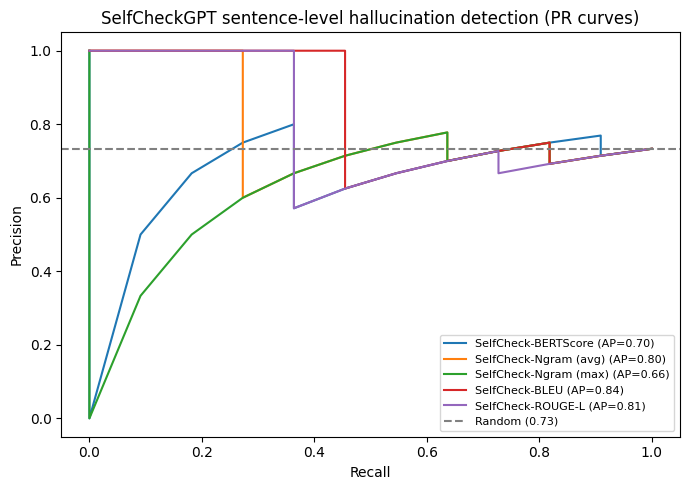

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
for name, scores in metrics.items():
    p, r, _ = precision_recall_curve(y, scores)
    plt.plot(r, p, label=f"{name} (AP={auc_pr[name]:.2f})")
plt.axhline(prevalence, ls="--", c="gray", label=f"Random ({prevalence:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("SelfCheckGPT sentence-level hallucination detection (PR curves)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


---
## Section 11. Passage-Level Ranking Correlation

The paper's second evaluation asks whether a passage's **average** SelfCheck score ranks passages by how
hallucinated they are. We compute, per question, the mean SelfCheck score and the mean proxy hallucination
rate, then report **Spearman** and **Pearson** correlation across questions. Higher positive correlation =
the score is a good passage-level hallucination detector.

In [16]:
from scipy.stats import spearmanr, pearsonr

passage = res.groupby("qid").agg(
    halluc_rate=("label_halluc", "mean"),
    bertscore=("bertscore", "mean"),
    ngram_avg=("ngram_avg", "mean"),
    bleu=("bleu", "mean"),
    rougeL=("rougeL", "mean"),
).reset_index()

print(f"{'metric':24s}  Spearman   Pearson")
for col in ["bertscore", "ngram_avg", "bleu", "rougeL"]:
    sp = spearmanr(passage[col], passage["halluc_rate"]).correlation
    pe = pearsonr(passage[col], passage["halluc_rate"])[0]
    print(f"  SelfCheck-{col:15s}  {sp:6.3f}    {pe:6.3f}")


metric                    Spearman   Pearson
  SelfCheck-bertscore        -0.140    -0.190
  SelfCheck-ngram_avg         0.000    -0.104
  SelfCheck-bleu              0.070    -0.050
  SelfCheck-rougeL           -0.070    -0.153


---
## Section 12. Inspect Flagged Sentences

Detection is only useful if we can act on it. We sort sentences by their BERTScore hallucination score and
show the most- and least-suspicious, alongside the proxy label and gold-similarity. This is the view a
clinician-facing system would surface for human review.

In [17]:
view = res.sort_values("bertscore", ascending=False)[
    ["bertscore", "bleu", "rougeL", "gold_cos", "label_halluc", "sentence"]
]
import pandas as pd
pd.set_option("display.max_colwidth", 90)
print("=== Most likely hallucinated (top BERTScore) ===")
print(view.head(5).to_string(index=False))
print("\n=== Most likely factual (bottom BERTScore) ===")
print(view.tail(5).to_string(index=False))


=== Most likely hallucinated (top BERTScore) ===
 bertscore     bleu   rougeL  gold_cos  label_halluc                     sentence
  0.453777 0.792410 0.763636  0.882800             0 Is jejunal atresia inherited
  0.436944 0.995572 0.810526  0.549791             1           a genetic disorder
  0.409496 1.000000 1.000000  0.034149             1                         womb
  0.383060 0.986547 0.785714  0.288032             1  Rapamycin and related drugs
  0.382499 0.964434 0.800000  0.012911             1                      sputum.

=== Most likely factual (bottom BERTScore) ===
 bertscore     bleu   rougeL  gold_cos  label_halluc                                                                                                  sentence
  0.131936 0.506443 0.359844  0.235026             1 subcutaneous injections of insulin-like growth factor 1 (a growth-promoting hormone), often called IGF-1.
  0.114690 0.286998 0.157143  0.267450             1                                         

---
## Section 13. Save Results

Persist the per-sentence scores and the metric summary so results can be reviewed or aggregated later.

In [18]:
from pathlib import Path
import json

OUT = Path("selfcheckgpt_results")
OUT.mkdir(exist_ok=True)
res.to_csv(OUT / "sentence_scores.csv", index=False)
json.dump(
    {"auc_pr": auc_pr, "prevalence": float(prevalence),
     "n_questions": int(res["qid"].nunique()), "n_sentences": int(len(res)),
     "n_samples": N_SAMPLES, "tau": TAU},
    open(OUT / "summary.json", "w"), indent=2,
)
print("Saved to", OUT.resolve())


Saved to /content/selfcheckgpt_results


---
## Section 14. Discussion Points for Journal Club

1. **Why does consistency imply factuality?** SelfCheckGPT assumes hallucinations are stochastic and
   non-reproducible. When does this assumption break — e.g. a model that hallucinates the *same* wrong fact
   every time? How would RAG grounding change the failure mode?

2. **Semantic vs. lexical scores** — Compare the AUC-PR of BERTScore against BLEU/ROUGE-L. When does
   surface overlap mislead (paraphrase, synonyms, numbers/units)? Which would you trust for medical text?

3. **Cost of sampling** — Detection quality generally rises with N samples but so does inference cost. How
   many samples are worth it here? Where is the knee of the curve?

4. **The proxy label caveat** — We labelled hallucination by similarity to the gold MedQuAD answer. How
   does the choice of `TAU` bias the AUC-PR? What would proper human annotation (as in WikiBio-GPT3) change?

5. **RAG + SelfCheck together** — RAG *reduces* hallucination by grounding; SelfCheckGPT *detects* residual
   hallucination without labels. How would you combine them into a safety layer — e.g. abstain, re-retrieve,
   or escalate to a human when the SelfCheck score is high?

6. **Black-box, zero-resource** — The method needs no token probabilities or knowledge base at detection
   time. Why is that valuable for closed API models, and what do you give up versus probability-based
   uncertainty methods?
